In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define Dataset Paths

In [ ]:
train_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/train/images"
val_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/validation/images"

Create ImageDataGenerator

In [ ]:
#training generator
train_datagen = ImageDataGenerator(

    rescale=1/255,

    rotation_range=10,

    width_shift_range=0.1,

    height_shift_range=0.1,

    zoom_range=0.1,

    horizontal_flip=False,

    vertical_flip=False

)

In [ ]:
#validation gererator (no argumentation, only normalization)

val_datagen = ImageDataGenerator(
    rescale=1/255
)

Create Training Dataset

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    color_mode="grayscale",

    class_mode="categorical",

    batch_size=32,

    shuffle=True

)

Found 1440 images belonging to 6 classes.


Create Validation Dataset

In [ ]:
validation_generator = val_datagen.flow_from_directory(

    val_path,

    target_size=(224,224),

    color_mode="grayscale",

    class_mode="categorical",

    batch_size=32,

    shuffle=False

)

Found 360 images belonging to 6 classes.


In [ ]:
train_generator.class_indices

{'crazing': 0,
 'inclusion': 1,
 'patches': 2,
 'pitted_surface': 3,
 'rolled-in_scale': 4,
 'scratches': 5}

Verify Batch Shape

In [ ]:
images, labels = next(train_generator)

print("Images Shape :", images.shape)

print("Labels Shape :", labels.shape)

Images Shape : (32, 224, 224, 1)
Labels Shape : (32, 6)


Visualize an Augmented Batch

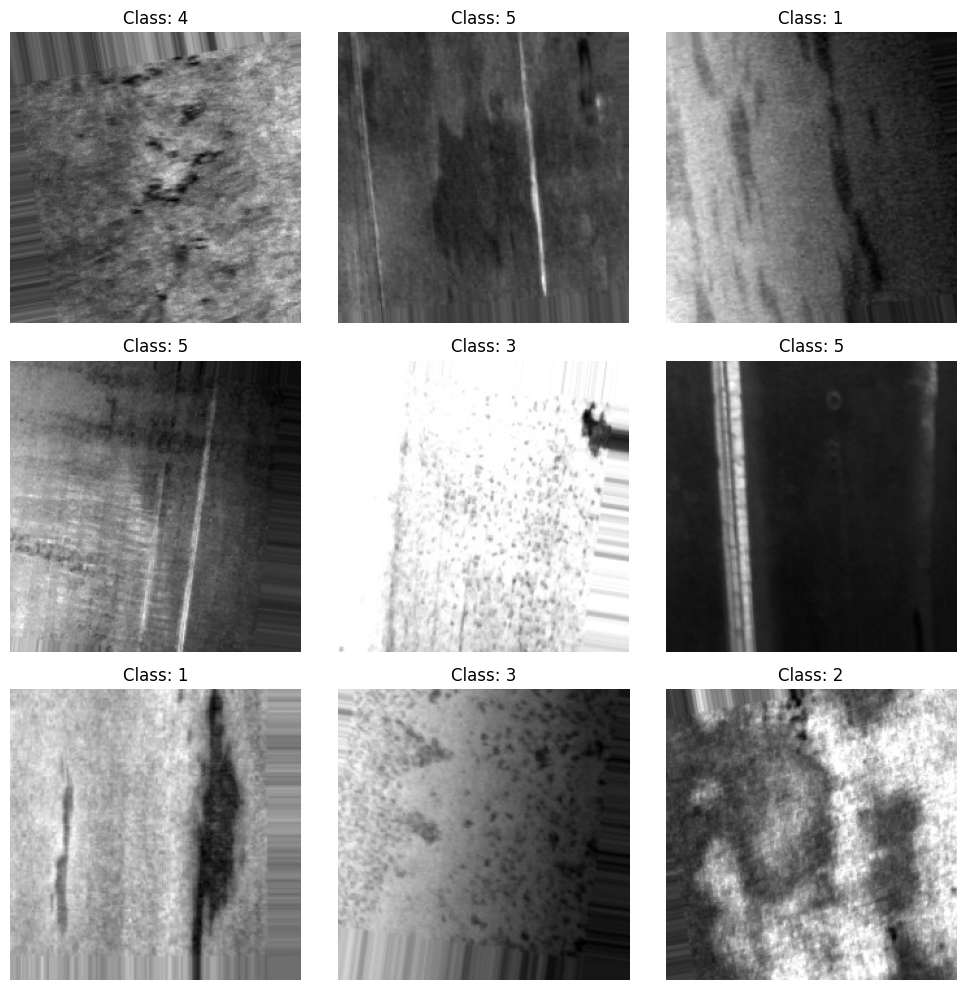

In [ ]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Class: {labels[i].argmax()}")

    plt.axis("off")

plt.tight_layout()

plt.show()